In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv(r"D:\GFG\Data Analysis Project\Dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [3]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [5]:
#replacing blanks with 0 as tenure is 0 and no total charges are recorded

df["TotalCharges"]=df["TotalCharges"].replace(" ","0")
df["TotalCharges"]=df["TotalCharges"].astype("float")

In [6]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [7]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df["customerID"].duplicated().sum()

np.int64(0)

In [10]:
# Converted 0/1 value in Senior Citizen to yes/no

In [11]:
def conv(value):
    if value==1:
        return "yes"
    else:
        return "no"

df["SeniorCitizen"]=df["SeniorCitizen"].apply(conv)

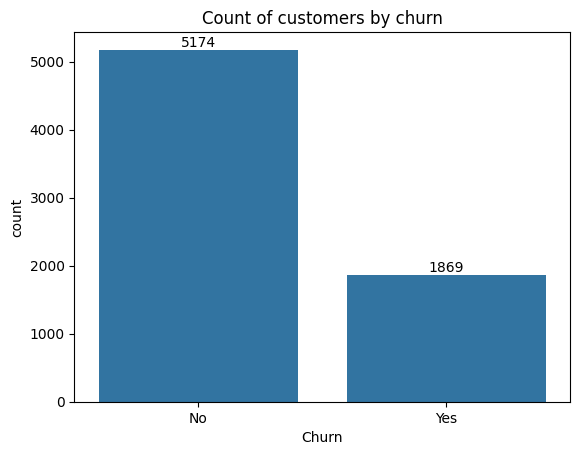

In [12]:
ax=sns.countplot(x= "Churn", data =df)
ax.bar_label(ax.containers[0])
plt.title("Count of customers by churn")
plt.show()

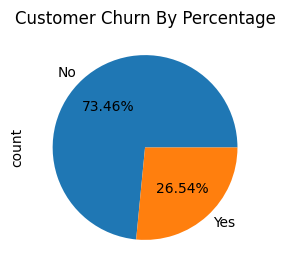

In [13]:
plt.figure(figsize=(4,3))
df["Churn"].value_counts().plot(kind='pie',autopct="%.2f%%")
plt.title("Customer Churn By Percentage")
plt.show()

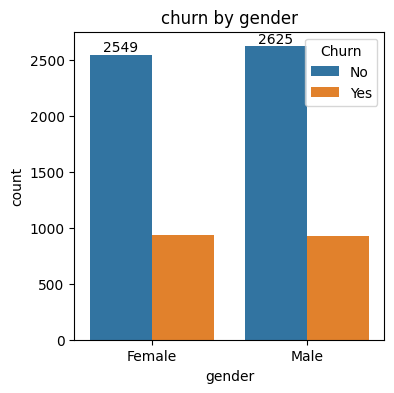

In [14]:
plt.figure(figsize=(4,4))
ax=sns.countplot(x="gender", hue="Churn",data=df)
ax.bar_label(ax.containers[0])
plt.title("churn by gender")
plt.show()

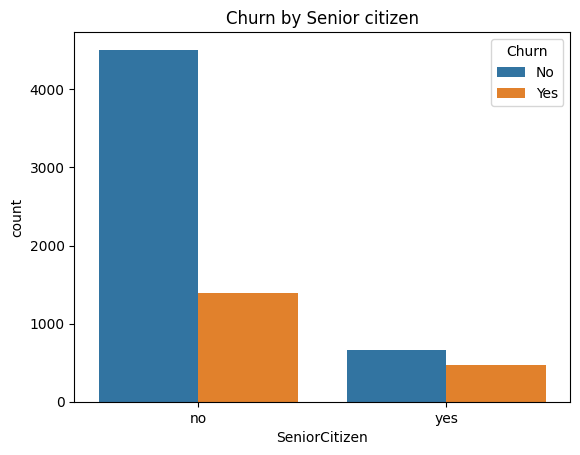

In [15]:
ax=sns.countplot(x= "SeniorCitizen", data =df,hue='Churn')
plt.title("Churn by Senior citizen")
plt.show()

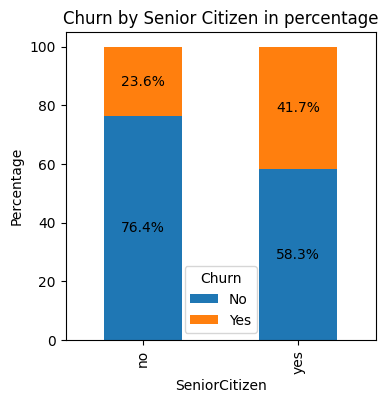

In [20]:
data = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100

ax = data.plot(kind='bar', stacked=True, figsize=(4,4))

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='center')

plt.title('Churn by Senior Citizen in percentage')
plt.ylabel('Percentage')
plt.show()

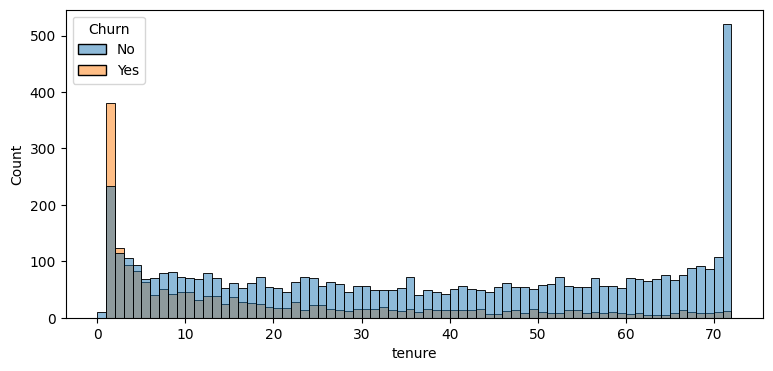

In [24]:
plt.figure(figsize=(9,4))
sns.histplot(x="tenure",data=df,hue="Churn",bins=72)
plt.show()

In [25]:
## The above chart shows customer who used serrvices for long time has stayed


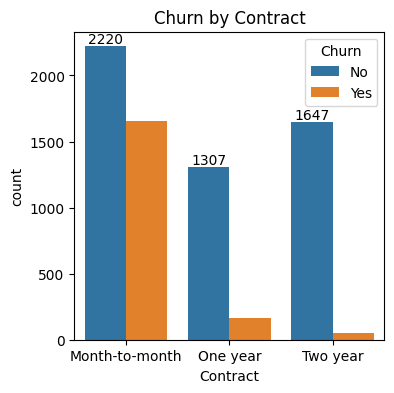

In [27]:
plt.figure(figsize=(4,4))
ax=sns.countplot(x="Contract",data=df,hue="Churn")
ax.bar_label(ax.containers[0])
plt.title("Churn by Contract")
plt.show()


In [28]:
# People who have month to month contarct are likely  to churn then people who have 1 or 2 year contract

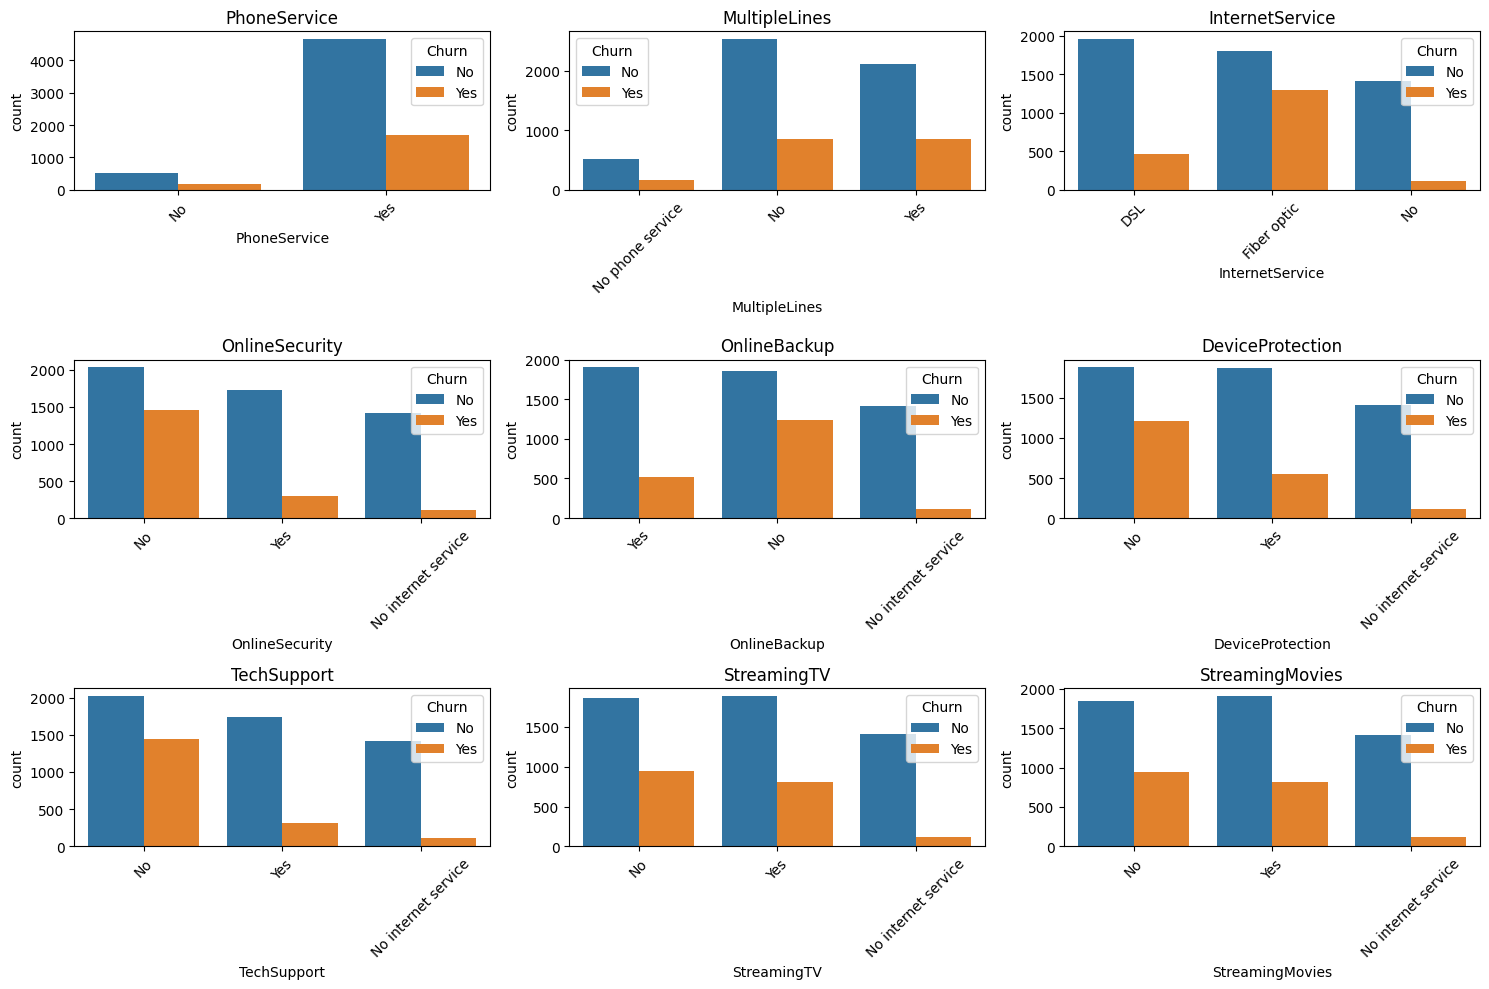

In [30]:

cols = ['PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

plt.figure(figsize=(15,10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)
    sns.countplot(x=col, data=df,hue="Churn")
    plt.title(col)
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

#Customers with fiber optic internet show the highest churn, making it the most critical risk factor. Value-added services like Online Security, Backup, Device Protection, and Tech Support significantly reduce churn, as customers without these services are more likely to leave. Phone service and multiple lines have little impact, while streaming services also do not strongly influence churn. Overall, support and security features are key to customer retention.
